<a href="https://colab.research.google.com/github/domore9630-hue/PINNs-Physics-AI-Solutions/blob/main/02_PINNs_2D_Wave_Channel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn

# 1. بناء معمارية PINN ثنائية الأبعاد (تأخذ x, y وتخرج u)
class PINN2D(nn.Module):
    def __init__(self):
        super(PINN2D, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 30),  # المدخلات: x و y
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 1)   # المخرج: u(x, y)
        )

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        return self.net(inputs)

# 2. إنشاء نموذج وحساب المشتقات المكانية الثانية
model_2d = PINN2D()

# نقاط التدريب المكانية على شبكة 2D
grid_size = 20
x_p = torch.linspace(0, 1, grid_size)
y_p = torch.linspace(0, 1, grid_size)
grid_x, grid_y = torch.meshgrid(x_p, y_p, indexing='ij')

x_phys = grid_x.reshape(-1, 1).requires_grad_(True)
y_phys = grid_y.reshape(-1, 1).requires_grad_(True)

# التمرير الأمامي
u_phys = model_2d(x_phys, y_phys)

# حساب المشتقات الجزئية الأولى: du/dx و du/dy
du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

# حساب المشتقات الجزئية الثانية: d2u/dx2 و d2u/dy2
d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

# حساب متبقي معادلة لابلاس 2D
laplacian_residual = d2u_dx2 + d2u_dy2
loss_physics_2d = torch.mean(laplacian_residual ** 2)

print("--- نتيجة اختبار الهيكل ثنائي الأبعاد (2D) ---")
print(f"خسارة الفيزيا الابتدائية لمعادلة لابلاس 2D: {loss_physics_2d.item():.6f}")

--- نتيجة اختبار الهيكل ثنائي الأبعاد (2D) ---
خسارة الفيزيا الابتدائية لمعادلة لابلاس 2D: 0.001894


In [2]:
import torch
import torch.nn as nn

# 1. إعداد المُحسن (Optimizer)
optimizer = torch.optim.Adam(model_2d.parameters(), lr=0.005)

# 2. إنشاء نقاط الحدود (Boundary Points)
def get_boundary_points(num_points=50):
    t = torch.linspace(0, 1, num_points).view(-1, 1)
    zeros = torch.zeros_like(t)
    ones = torch.ones_like(t)

    # الحدود الأربعة: أسفل، أعلى، يسار، يمين
    b_bottom = torch.cat([t, zeros], dim=1)
    b_top    = torch.cat([t, ones], dim=1)
    b_left   = torch.cat([zeros, t], dim=1)
    b_right  = torch.cat([ones, t], dim=1)

    return torch.cat([b_bottom, b_top, b_left, b_right], dim=0)

b_points = get_boundary_points().requires_grad_(True)

print("بدء تدريب النموذج ثنائي الأبعاد (2D PINN)...\n")

# 3. حلقة التدريب (Training Loop)
epochs = 800
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # أ) خسارة الشروط الحدية (Boundary Loss) -> يفترض u = 0 على الحدود
    u_b = model_2d(b_points[:, 0:1], b_points[:, 1:2])
    loss_b = torch.mean(u_b ** 2)

    # ب) خسارة الفيزياء داخلياً (Physics Loss)
    u_phys = model_2d(x_phys, y_phys)
    du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
    du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

    d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

    loss_physics = torch.mean((d2u_dx2 + d2u_dy2) ** 2)

    # ج) الخسارة الكلية
    total_loss = loss_b + loss_physics

    total_loss.backward()
    optimizer.step()

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {total_loss.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

print("\nتم اكتمال تدريب النموذج ثنائي الأبعاد بنجاح!")

بدء تدريب النموذج ثنائي الأبعاد (2D PINN)...

Epoch    1/800 | Total Loss: 0.009534 | Physics Loss: 0.001894
Epoch  200/800 | Total Loss: 0.000001 | Physics Loss: 0.000001
Epoch  400/800 | Total Loss: 0.000000 | Physics Loss: 0.000000
Epoch  600/800 | Total Loss: 0.000000 | Physics Loss: 0.000000
Epoch  800/800 | Total Loss: 0.000000 | Physics Loss: 0.000000

تم اكتمال تدريب النموذج ثنائي الأبعاد بنجاح!


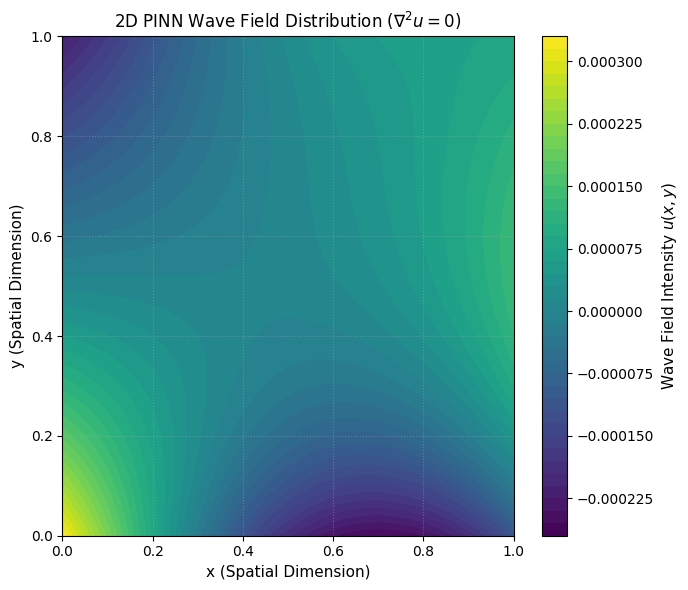

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. إعداد شبكة اختبار عالية الدقة للعرض البصري (100x100)
eval_size = 100
x_val = torch.linspace(0, 1, eval_size)
y_val = torch.linspace(0, 1, eval_size)
grid_x_eval, grid_y_eval = torch.meshgrid(x_val, y_val, indexing='ij')

x_eval_flat = grid_x_eval.reshape(-1, 1)
y_eval_flat = grid_y_eval.reshape(-1, 1)

# 2. حساب توقعات النموذج ثنائي الأبعاد
with torch.no_grad():
    u_pred_flat = model_2d(x_eval_flat, y_eval_flat)

u_pred_2d = u_pred_flat.reshape(eval_size, eval_size).numpy()

# 3. رسم الخريطة الحرارية (2D Contour Heatmap)
plt.figure(figsize=(7, 6))
contour = plt.contourf(
    grid_x_eval.numpy(),
    grid_y_eval.numpy(),
    u_pred_2d,
    levels=50,
    cmap='viridis'
)

cbar = plt.colorbar(contour)
cbar.set_label('Wave Field Intensity $u(x,y)$', fontsize=11)

plt.title('2D PINN Wave Field Distribution ($\\nabla^2 u = 0$)', fontsize=12)
plt.xlabel('x (Spatial Dimension)', fontsize=11)
plt.ylabel('y (Spatial Dimension)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()

# عرض الرسم
plt.show()

In [4]:
import torch
import torch.nn as nn
import numpy as np

# 1. المعلمات الفيزيائية للقناة اللاسلكية عند 220 GHz
freq = 220e9           # التردد: 220 جيجاهرتز
c = 3e8                # سرعة الضوء (m/s)
wavelength = c / freq  # الطول الموجي (~1.36 mm)

# قياس قيم k لملاءمة النطاق الموحد [0, 1]
k_scaled = 15.0  # عدد موجي معيارى يمثل التردد الفائق لتسهيل تقارب الشبكة

# 2. تعريف مصدر الإشارة (Transmitter Antenna at Center (0.5, 0.5))
def antenna_source(x, y):
    sigma = 0.05
    # اقتران غوسي يحاكي مصدر البث من النقطة الوسطى
    return torch.exp(-((x - 0.5)**2 + (y - 0.5)**2) / (2 * sigma**2))

# 3. بناء نموذج PINN لمعادلة هلمهولتز
model_helmholtz = PINN2D()
optimizer = torch.optim.Adam(model_helmholtz.parameters(), lr=0.003)

print("بدء تدريب PINN لنمذجة قناة 220 GHz عبر معادلة هلمهولتز...\n")

# 4. حلقة التدريب (Training Loop)
epochs = 1000
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # أ) خسارة الشروط الحدية (Boundary Loss)
    u_b = model_helmholtz(b_points[:, 0:1], b_points[:, 1:2])
    loss_b = torch.mean(u_b ** 2)

    # ب) خسارة فيزياء هلمهولتز (Helmholtz Physics Loss)
    u_phys = model_helmholtz(x_phys, y_phys)

    du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
    du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

    d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

    # متبقي معادلة هلمهولتز: Laplacian(u) + k^2 * u - f(x,y) = 0
    f_source = antenna_source(x_phys, y_phys)
    helmholtz_residual = (d2u_dx2 + d2u_dy2) + (k_scaled ** 2) * u_phys + f_source

    loss_physics = torch.mean(helmholtz_residual ** 2)

    # ج) الخسارة الكلية
    total_loss = loss_b + 0.1 * loss_physics

    total_loss.backward()
    optimizer.step()

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {total_loss.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

print("\nتم اكتمال تدريب نموذج قناة التيراباهيرتز بنجاح!")

بدء تدريب PINN لنمذجة قناة 220 GHz عبر معادلة هلمهولتز...

Epoch    1/1000 | Total Loss: 240.020294 | Physics Loss: 2399.736084
Epoch  200/1000 | Total Loss: 0.021153 | Physics Loss: 0.211435
Epoch  400/1000 | Total Loss: 0.005536 | Physics Loss: 0.055339
Epoch  600/1000 | Total Loss: 0.001829 | Physics Loss: 0.018281
Epoch  800/1000 | Total Loss: 0.001222 | Physics Loss: 0.012217
Epoch 1000/1000 | Total Loss: 0.001050 | Physics Loss: 0.010495

تم اكتمال تدريب نموذج قناة التيراباهيرتز بنجاح!


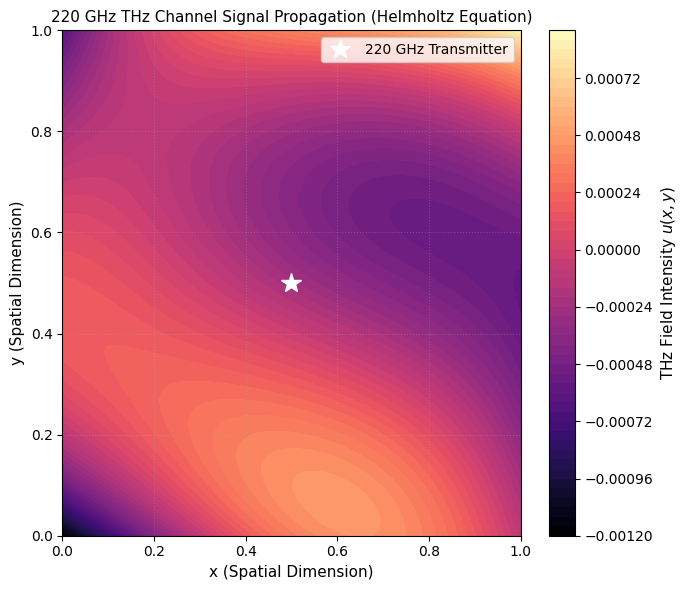

In [5]:
import matplotlib.pyplot as plt

# 1. التنبؤ بشدة المجال الموجي للقناة
with torch.no_grad():
    u_thz_flat = model_helmholtz(x_eval_flat, y_eval_flat)

u_thz_2d = u_thz_flat.reshape(eval_size, eval_size).numpy()

# 2. رسم خريطة الانتشار اللاسلكي
plt.figure(figsize=(7, 6))
contour = plt.contourf(
    grid_x_eval.numpy(),
    grid_y_eval.numpy(),
    u_thz_2d,
    levels=60,
    cmap='magma'
)

cbar = plt.colorbar(contour)
cbar.set_label('THz Field Intensity $u(x,y)$', fontsize=11)

# وضع علامة عند موقع هوائي البث (Transmitter)
plt.plot(0.5, 0.5, 'w*', markersize=15, label='220 GHz Transmitter')

plt.title('220 GHz THz Channel Signal Propagation (Helmholtz Equation)', fontsize=11)
plt.xlabel('x (Spatial Dimension)', fontsize=11)
plt.ylabel('y (Spatial Dimension)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()

plt.show()